# Trained Lilylet M3 student — visualize on a local dataset

Loads the **trained** `LilyletM3Encoder` student from the lr0.06-wu1000 run
(`best.chkpt`, epoch 563, val cos ~0.915 on the 100K NotaGen corpus) and evaluates
it on the local 215-sample artifact `~/data/lilylet/m3/notagenx-from-abc.pt`.

These 215 pieces are **not** in the 100K training corpus, so this doubles as an
out-of-distribution check: how well does the student reproduce the frozen ABC M3
teacher's pooled embedding on unseen pieces?

1. Load the trained student + the local paired artifact
2. Per-sample student↔teacher cosine (the trained alignment)
3. Student vs teacher — PCA scatter, colored by period / genre
4. Cross-piece cosine-similarity matrices (student vs teacher side by side)
5. Nearest-neighbour retrieval: does the student preserve the teacher's neighbours?

Run from this directory (`tests/lilylet/`).

In [1]:
from pathlib import Path
import sys, collections

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import torch.nn.functional as F

from starry.utils.model_factory import loadModel

CKPT = '/home/camus/data/models/deep-starry-logs/lilylet/20260620-lilylet-m3-distill-0619-lr0.06-wu1000/best.chkpt'
ART = Path.home() / 'data/lilylet/m3/notagenx-from-abc.pt'
print('checkpoint:', CKPT)
print('artifact  :', ART)

checkpoint: /home/camus/data/models/deep-starry-logs/lilylet/20260620-lilylet-m3-distill-0619-lr0.06-wu1000/best.chkpt
artifact  : /home/camus/data/lilylet/m3/notagenx-from-abc.pt


## 1. Load the trained student + the local artifact

The checkpoint stores the deducer (`encoder.*` + `proj.*`). Build a
`LilyletM3Encoder` with the run's model args and load the weights (strict).

In [2]:
art = torch.load(ART, weights_only=False)
items = art['items']
print('format:', art['format'], '| items:', len(items))
print('m3:', art['config']['m3'])

# model args from the lr0.06-wu1000 config (mse_weight is harmlessly swallowed by the encoder)
MODEL_ARGS = dict(num_classes=256, hidden_size=768, patch_size=64, patch_length=512,
                  patch_num_layers=12, n_head=12, project=True, warm_start=False)
deducer = loadModel({'type': 'LilyletM3Encoder', 'args': MODEL_ARGS},
                    imports=['starry.lilylet.models.m3distill'])

ck = torch.load(CKPT, map_location='cpu', weights_only=False)
print('checkpoint epoch:', ck.get('epoch'))
missing, unexpected = deducer.load_state_dict(ck['model'], strict=True)
deducer.eval()
n_params = sum(p.numel() for p in deducer.parameters())
print('loaded LilyletM3Encoder: %.2fM params (missing=%d unexpected=%d)'
      % (n_params / 2**20, len(missing), len(unexpected)))

format: lilylet-m3-abc-pooled | items: 215
m3: {'weights': '/home/camus/.cache/huggingface/hub/models--sander-wood--clamp3/snapshots/355625cc1c6f73726bbcd0eb9276ac7152d56426/weights_clamp3_saas_h_size_768_t_model_FacebookAI_xlm-roberta-base_t_length_128_a_size_768_a_layers_12_a_length_128_s_size_768_s_layers_12_p_size_64_p_length_512.pth', 'hidden': 768, 'patch_size': 64, 'pooling': 'mean'}


checkpoint epoch: 563
loaded LilyletM3Encoder: 94.62M params (missing=0 unexpected=0)


## Parse metadata from filenames

Filenames follow `DATE_TIME_Period_Composer_Genre_postinst.lyl`.

In [3]:
def parse_meta(path):
    parts = Path(path).stem.split('_')
    return dict(period=parts[2] if len(parts) > 2 else '?',
                composer=parts[3] if len(parts) > 3 else '?',
                genre=parts[4] if len(parts) > 4 else '?')

meta = [parse_meta(it['path']) for it in items]
print('periods:', dict(collections.Counter(m['period'] for m in meta)))
print('genres :', dict(collections.Counter(m['genre'] for m in meta)))

periods: {'Baroque': 2, 'Classical': 93, 'Romantic': 120}
genres : {'Keyboard': 134, 'Art Song': 12, 'Orchestral': 41, 'Chamber': 28}


## 2. Compute student & teacher embeddings for all pieces

Run the trained student over every piece's stored Lilylet patches (the same input
the training feeder uses). The teacher target is the artifact's stored pooled
`m3_embedding`. Report the per-sample cosine alignment.

In [4]:
student = []
teacher = []
with torch.no_grad():
    for it in items:
        p = it['patches'].long().unsqueeze(0)                 # [1, T, 64]
        m = torch.ones(1, p.shape[1], dtype=torch.long)
        emb = deducer(p, m)[0]                                 # [768]
        student.append(emb)
        teacher.append(it['m3_embedding'].float())
student = torch.stack(student)                                # [N, 768]
teacher = torch.stack(teacher)
cos = F.cosine_similarity(student, teacher, dim=-1)           # [N]
print('student↔teacher cosine  min/median/mean/max: %.3f / %.3f / %.3f / %.3f'
      % (cos.min(), cos.median(), cos.mean(), cos.max()))
print('pieces with cos > 0.9: %d / %d' % (int((cos > 0.9).sum()), len(items)))

student↔teacher cosine  min/median/mean/max: 0.747 / 0.915 / 0.914 / 0.989
pieces with cos > 0.9: 129 / 215


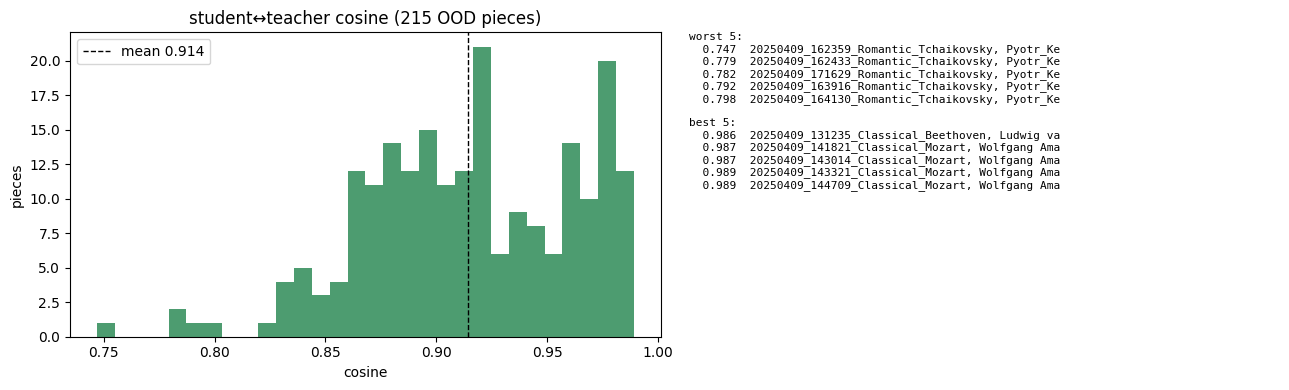

In [5]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(cos.numpy(), bins=30, color='seagreen', alpha=0.85)
ax[0].axvline(cos.mean().item(), color='k', ls='--', lw=1, label='mean %.3f' % cos.mean())
ax[0].set_title('student↔teacher cosine (215 OOD pieces)')
ax[0].set_xlabel('cosine'); ax[0].set_ylabel('pieces'); ax[0].legend()

# worst / best pieces
order = cos.argsort()
ax[1].axis('off')
lines = ['worst 5:'] + ['  %.3f  %s' % (cos[i], Path(items[i]['path']).stem[:46]) for i in order[:5].tolist()]
lines += ['', 'best 5:'] + ['  %.3f  %s' % (cos[i], Path(items[i]['path']).stem[:46]) for i in order[-5:].tolist()]
ax[1].text(0, 1, '\n'.join(lines), family='monospace', fontsize=8, va='top')
plt.tight_layout(); plt.show()

## 3. Student vs teacher — PCA scatter (period / genre)

Project both embedding sets to 2-D with a **shared** PCA basis (fit on the teacher,
applied to both) so the two scatters are directly comparable. If the student learned
the teacher's space, the two layouts and their period/genre clustering should match.

In [6]:
# shared PCA basis from the teacher
Xt = teacher - teacher.mean(dim=0, keepdim=True)
U, S, Vh = torch.linalg.svd(Xt, full_matrices=False)
basis = Vh[:2].T
var = (S ** 2 / (S ** 2).sum())[:2].numpy()
mean_t = teacher.mean(dim=0, keepdim=True)
pcs_t = ((teacher - mean_t) @ basis).numpy()
pcs_s = ((student - mean_t) @ basis).numpy()
print('explained variance PC1/PC2: %.1f%% / %.1f%%' % (var[0]*100, var[1]*100))

explained variance PC1/PC2: 21.0% / 6.0%


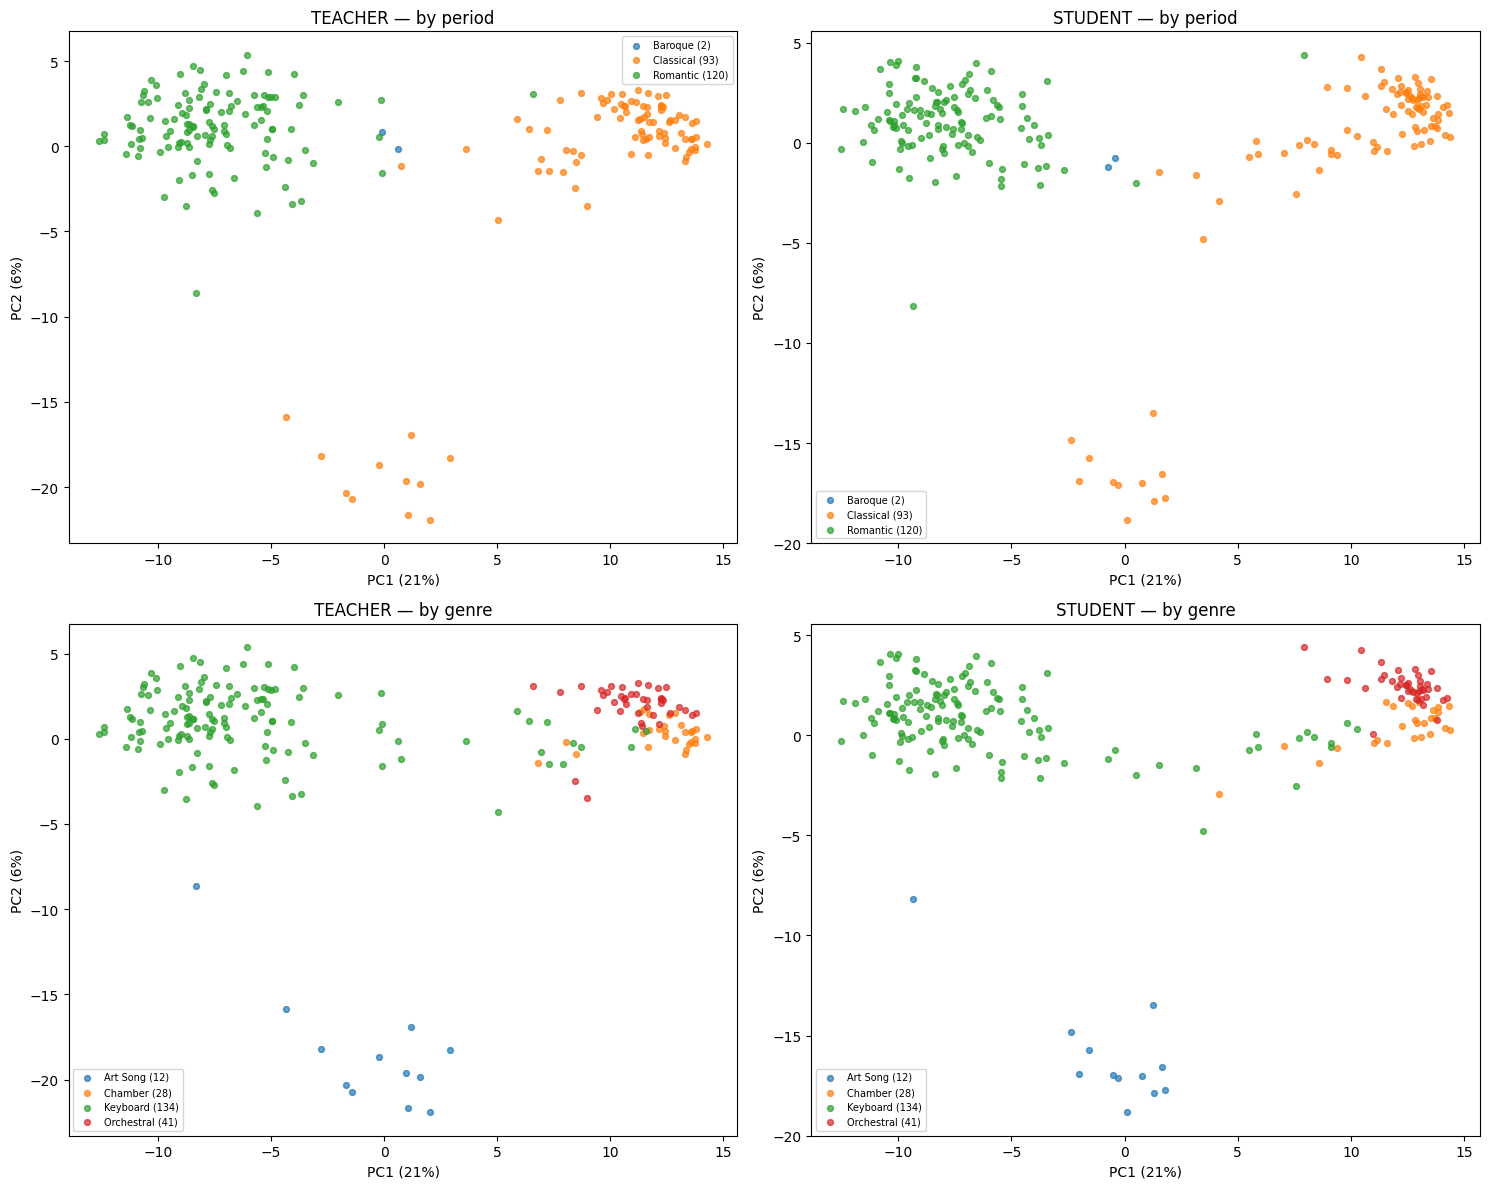

In [7]:
def scatter_by(pcs, key, ax, title):
    labels = [m[key] for m in meta]
    cmap = plt.get_cmap('tab10')
    for i, cat in enumerate(sorted(set(labels))):
        sel = [j for j, l in enumerate(labels) if l == cat]
        ax.scatter(pcs[sel, 0], pcs[sel, 1], s=18, alpha=0.7, color=cmap(i % 10), label='%s (%d)' % (cat, len(sel)))
    ax.set_title(title); ax.set_xlabel('PC1 (%.0f%%)' % (var[0]*100)); ax.set_ylabel('PC2 (%.0f%%)' % (var[1]*100))
    ax.legend(fontsize=7)

fig, ax = plt.subplots(2, 2, figsize=(15, 12))
scatter_by(pcs_t, 'period', ax[0,0], 'TEACHER — by period')
scatter_by(pcs_s, 'period', ax[0,1], 'STUDENT — by period')
scatter_by(pcs_t, 'genre',  ax[1,0], 'TEACHER — by genre')
scatter_by(pcs_s, 'genre',  ax[1,1], 'STUDENT — by genre')
plt.tight_layout(); plt.show()

## 4. Cross-piece cosine-similarity matrices (student vs teacher)

Pairwise cosine between pooled vectors, sorted by period/genre. The student's matrix
should reproduce the teacher's block structure if it preserved relative geometry.

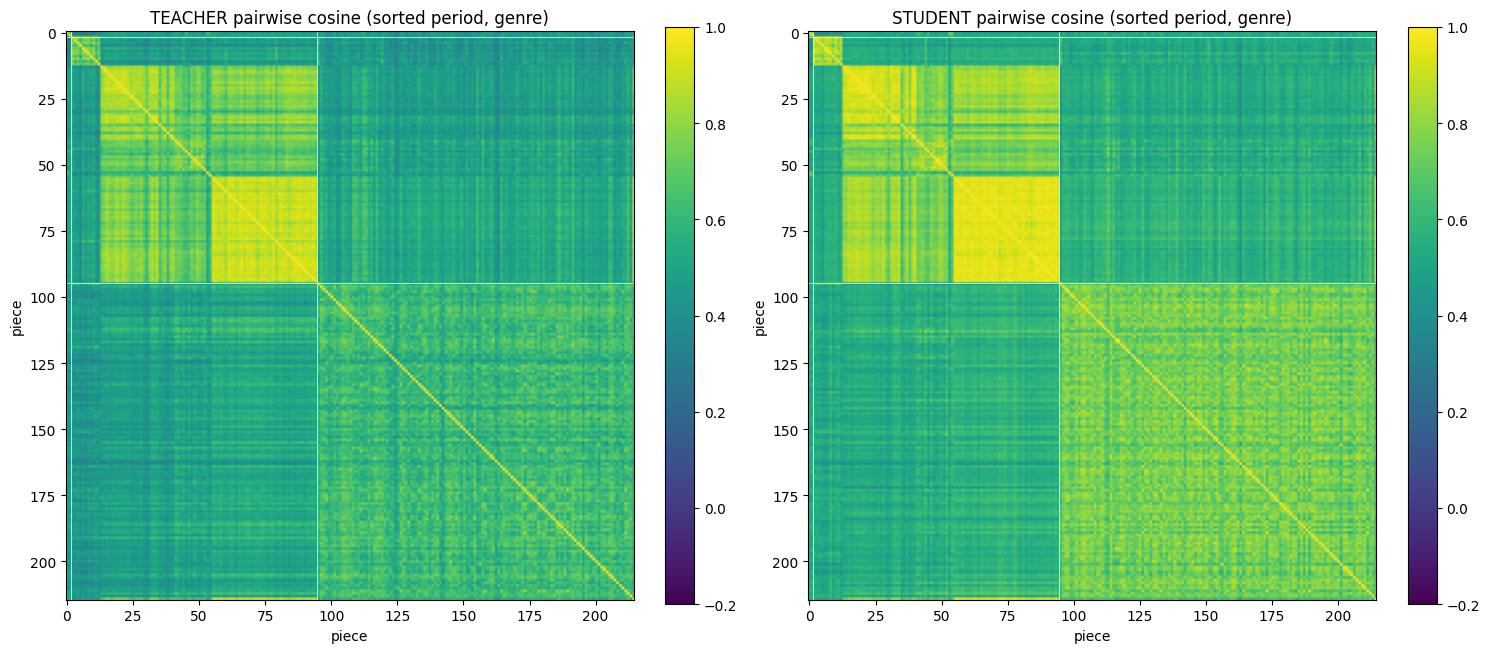

correlation of off-diagonal similarities (teacher vs student): 0.892


In [8]:
order_idx = sorted(range(len(items)), key=lambda j: (meta[j]['period'], meta[j]['genre']))
def simmat(emb):
    P = F.normalize(emb[order_idx], dim=1)
    return (P @ P.T).numpy()
sim_t, sim_s = simmat(teacher), simmat(student)

fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
for a, sim, title in [(ax[0], sim_t, 'TEACHER'), (ax[1], sim_s, 'STUDENT')]:
    im = a.imshow(sim, cmap='viridis', vmin=-0.2, vmax=1.0)
    a.set_title('%s pairwise cosine (sorted period, genre)' % title)
    a.set_xlabel('piece'); a.set_ylabel('piece')
    fig.colorbar(im, ax=a, fraction=0.046)
    sp = [meta[j]['period'] for j in order_idx]
    for b in [k for k in range(1, len(sp)) if sp[k] != sp[k-1]]:
        a.axhline(b-0.5, color='w', lw=0.5); a.axvline(b-0.5, color='w', lw=0.5)
plt.tight_layout(); plt.show()

# how faithfully does the student preserve the teacher's pairwise structure?
iu = np.triu_indices(len(items), k=1)
r = np.corrcoef(sim_t[iu], sim_s[iu])[0, 1]
print('correlation of off-diagonal similarities (teacher vs student): %.3f' % r)

## 5. Nearest-neighbour retrieval agreement

For each piece, does the student's top-k nearest neighbours (by cosine) match the
teacher's? This is the practical cross-modal-retrieval test: high overlap means the
student can stand in for the teacher's symbolic embedding.

top-5 neighbour overlap (student vs teacher)  mean: 47.3%  (median 40%)
pieces with full top-5 match: 7 / 215


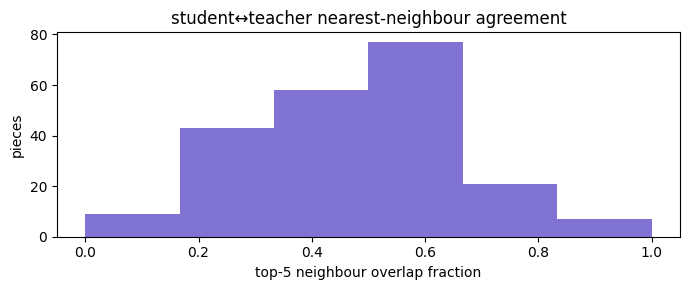

In [9]:
def topk_neighbours(emb, k=5):
    P = F.normalize(emb, dim=1)
    sim = P @ P.T
    sim.fill_diagonal_(-2.0)
    return sim.topk(k, dim=1).indices

K = 5
nn_t, nn_s = topk_neighbours(teacher, K), topk_neighbours(student, K)
overlap = np.array([len(set(nn_t[i].tolist()) & set(nn_s[i].tolist())) / K for i in range(len(items))])
print('top-%d neighbour overlap (student vs teacher)  mean: %.1f%%  (median %.0f%%)'
      % (K, overlap.mean()*100, np.median(overlap)*100))
print('pieces with full top-%d match: %d / %d' % (K, int((overlap == 1.0).sum()), len(items)))

plt.figure(figsize=(7, 3))
plt.hist(overlap, bins=np.linspace(0, 1, K+2), color='slateblue', alpha=0.85)
plt.xlabel('top-%d neighbour overlap fraction' % K); plt.ylabel('pieces')
plt.title('student↔teacher nearest-neighbour agreement'); plt.tight_layout(); plt.show()